In [64]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import  pyplot as plt 

In [63]:
base_dir = f"../../artifacts/2024-03-s22/experiments/accuracy-curves/2-logit-pcafilter"

In [65]:
def read_data(dataset, model, layer, logit_mod, basis_name, gamma):
    model = model
    layer = layer
    df = pd.read_csv(
        f"{base_dir}/{dataset}/{model}/{logit_mod}/{layer}/{basis_name}--gamma{gamma}.csv"
    )
    return df

read_data(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    layer="features.23",
    logit_mod="winninglogit",
    basis_name="pca",
    gamma=0.25
)

FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2024-03-s22/experiments/accuracy-curves/2-logit-pcafilter/imagenet-butterfly/imagenet-vgg16-tv/winninglogit/features.23/pca--gamma0.25.csv'

In [27]:
import re
def find_ratios(names):
    
    arr = []
    
    for t in names:
        m = re.match(r"pca([\.\d]+)prcasortabs", t)
        if m:
            arr.append(float(m.group(1)))
            
    
    return arr

find_ratios([
        "pca",
        "prcasortabs",
        "pca0.1prcasortabs",
        "pca0.25prcasortabs",
        "pca0.5prcasortabs",
        "pca1.0prcasortabs",
    ])

[0.1, 0.25, 0.5, 1.0]

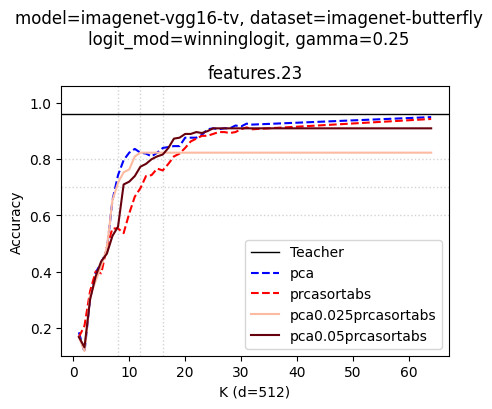

In [90]:
def alias(name):
    return name
    if "pca" in name:
        return "PCA"
    elif "prca" in name:
        gamma = name.split("--gamma")[1]
        return f"PRCA-sortabs($\\gamma={gamma}$)"
    else:
        raise

def ls(name):
    if name in ["pca", "prcasortabs"]:
        return "--"
    else:
        return "-"
    
def viz(
    dataset,
    model,
    arr_layers,
    logit_mod,
    gamma=0.25,
    arr_basis_names=[
       "pca",
       "prcasortabs",  
    ],
):
    
    ncols = len(arr_layers)
    plt.figure(figsize=(5*ncols, 3.5))
    plt.suptitle(f"model={model}, dataset={dataset}\nlogit_mod={logit_mod}, gamma={gamma}", y=1.1)

        
    
    arr_ratios = np.array(find_ratios(arr_basis_names))
    color_index = np.linspace(0.25, 1, len(arr_ratios))
    cmap_reds = mpl.colormaps.get_cmap("Reds")

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prcasortabs":
            return "red"
        elif re.match(r"pca([\.\d]+)prcasortabs", name):
            ratio = float(re.match(r"pca([\.\d]+)prcasortabs", name).group(1))

            ix = np.argwhere(arr_ratios == ratio).reshape(-1)[0]
            return cmap_reds(color_index[ix])
            return mpl.colormaps.get_cmap("Reds")(ratio + 0.1)
        else:
            raise
        
    for lix, (layer, max_k) in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        
        plt.title(layer)
        plt.axhline(0.8, ls=":", lw=1, color="lightgray")

        plt.axhline(0.7, ls=":", lw=1, color="lightgray")

        plt.axhline(0.6, ls=":", lw=1, color="lightgray")
        plt.axvline(8, ls=":", lw=1, color="lightgray")
        plt.axvline(12, ls=":", lw=1, color="lightgray")

        plt.axvline(16, ls=":", lw=1, color="lightgray")

        for bix, basis_name in enumerate(arr_basis_names):
            df = read_data(
                dataset=dataset,
                model=model,
                layer=layer,
                basis_name=basis_name,
                logit_mod=logit_mod,
                gamma=gamma,
            )
            dims = df.k.max()
            
            if bix == 0:
                ref_acc = df[df.k == df.k.max()].acc.values[0]
                plt.axhline(
                    ref_acc, ls="-", label="Teacher", 
                    color="k",
                    lw=1
                )
                plt.ylim([0.1, ref_acc+0.1])
            _df = df[df.k <= max_k]

            plt.plot(
                _df.k,
                _df.acc,
                ls=ls(basis_name),
                color=color(basis_name),
                label=alias(basis_name)
            )
            plt.xlabel(f"K (d={dims})")
        
        plt.ylabel("Accuracy")
        
        if lix == 0:
            plt.legend()
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_layers=[
#         ("features.9", 32),
#         ("features.16", 64),
        ("features.23", 64),
#         ("features.30", 32),
    ],
    arr_basis_names=[
        "pca",
        "prcasortabs",
        "pca0.025prcasortabs",
        "pca0.05prcasortabs",
#         "pca0.1prcasortabs",
#         "pca0.25prcasortabs",
    ],
    logit_mod="winninglogit",
)

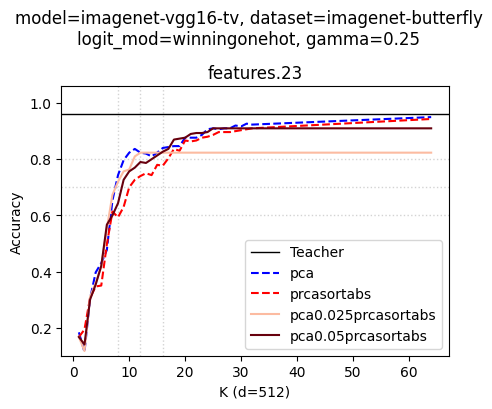

In [91]:
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_layers=[
#         ("features.9", 32),
#         ("features.16", 64),
        ("features.23", 64),
#         ("features.30", 32),
    ],
    arr_basis_names=[
        "pca",
        "prcasortabs",
        "pca0.025prcasortabs",
        "pca0.05prcasortabs",
#         "pca0.1prcasortabs",
#         "pca0.25prcasortabs",
    ],
    logit_mod="winningonehot",
    gamma=0.25
)

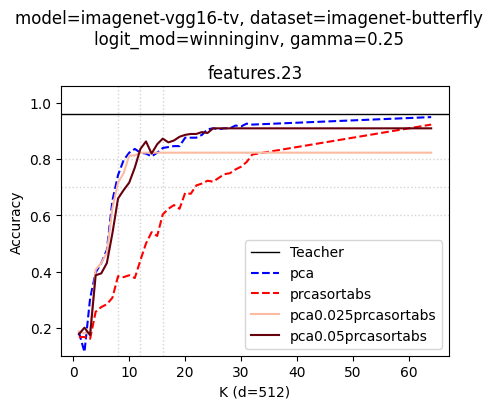

In [93]:
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_layers=[
#         ("features.9", 32),
#         ("features.16", 64),
        ("features.23", 64),
#         ("features.30", 32),
    ],
    arr_basis_names=[
        "pca",
        "prcasortabs",
        "pca0.025prcasortabs",
        "pca0.05prcasortabs",
#         "pca0.1prcasortabs",
#         "pca0.25prcasortabs",
    ],
    logit_mod="winninginv",
    gamma=0.25
)